In [8]:
import pandas as pd
import os

#### Merging 12 months of sales data into a single file

In [15]:
df = pd.read_csv("./SalesAnalysis/Sales_Data/Sales_April_2019.csv")
files = [file for file in os.listdir("./SalesAnalysis/Sales_Data") if file.endswith(".csv")]
all_month_data = pd.DataFrame()
for file in files:
    df = pd.read_csv("./SalesAnalysis/Sales_Data/" + file)
    all_month_data = pd.concat([all_month_data, df])
all_month_data.to_csv("./SalesAnalysis/Sales_Data/all_month_data.csv", index=False)

In [17]:
all_data = pd.read_csv("./SalesAnalysis/Sales_Data/all_month_data.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",NaN
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",NaN
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035",NaN
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",NaN
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",NaN


### Clean up the data!

#### Drop rows of NAN

In [25]:
nan_df = all_data[all_data.isna().any(axis=1)]
all_data = all_data.dropna(how='all')
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,08
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,08
97994,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,08
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,08
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,08


#### Find 'Or' and delete it

In [31]:
all_data = all_data[all_data['Order Date'].str[0:2] != 'Or']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,08
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,08
97994,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,08
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,08
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,08


##### Convert columns to the correct type

In [35]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered']) # Make int
all_data['Price Each'] = pd.to_numeric(all_data['Price Each']) # Make float

### Augment data with aditional columns

### Task 2: Add Month Column

In [36]:
all_data['Month'] = all_data['Order Date'].str[0:2]
all_data['Month'] = all_data['Month'].astype('int32')
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,8
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,8
97994,236672,iPhone,1,700.00,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,8
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,8
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,8


#### Task 3: Add a sales column

In [37]:
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month,Sales
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,8,23.98
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,8,99.99
97994,236672,iPhone,1,700.00,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,8,700.00
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,8,7.68
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,8,7.68


#### Task 4: Add a city column

In [45]:
# Let's use the .apply() method

all_data['Column'] = all_data['Purchase Address'].apply(lambda x: x.split(',')[1])
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month,Sales,Column
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,8,23.98,Seattle
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,8,99.99,Dallas
97994,236672,iPhone,1,700.00,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,8,700.00,Portland
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,8,7.68,Los Angeles
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,8,7.68,New York City


#### Question 1 What was the best month for sales? How much was earned that month?

In [43]:
results  = all_data.groupby('Month').sum()

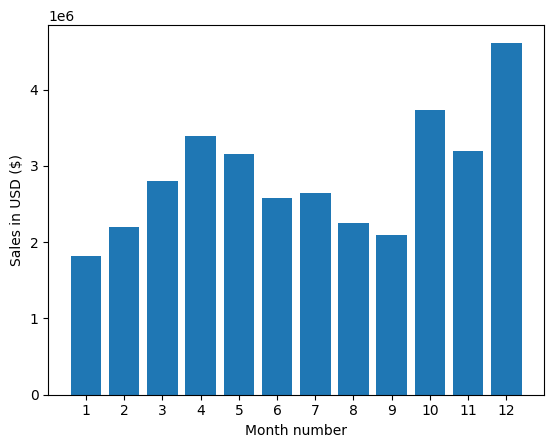

In [44]:
import matplotlib.pyplot as plt

months = range(1,13)

plt.bar(months, results['Sales'])
plt.xticks(months)
plt.ylabel('Sales in USD ($)')
plt.xlabel('Month number')
plt.show()

### What city had the best sales

In [ ]:
cresults = all_data.groupby('').sum()